In [3]:
# ==============================================================================
#           BLOCCO 0: SETUP, CARICAMENTO DATI E PREPARAZIONE
# ==============================================================================
# Esegui questo blocco UNA SOLA VOLTA all'inizio della sessione.

import os
import sys
import json
import glob
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- Gestione di Google Colab ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

PROJECT_ROOT = '/content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab'
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src import data_loader, models

# --- Configurazione Generale ---
PIPELINE_NAME = "Ensemble_OneVsRest"
BINARY_MODEL_CREATOR_FN = models.create_binary_classifier_model

# Definisci percorsi
FEATURES_DIR = os.path.join(PROJECT_ROOT, "data/processed/features_v2")
BINARY_MODELS_DIR = os.path.join(PROJECT_ROOT, "models", "binary_classifiers")
CSV_PATH = os.path.join(PROJECT_ROOT, "data/raw/UrbanSound8K.csv")

os.makedirs(BINARY_MODELS_DIR, exist_ok=True)
print(f"--- PREPARAZIONE PIPELINE: {PIPELINE_NAME} ---")
print(f"I modelli binari verranno salvati in: {BINARY_MODELS_DIR}")

# --- Caricamento dati e Split ---
print("\nCaricamento dati e creazione split train/test...")
all_data = {}
fold_dirs = sorted(glob.glob(os.path.join(FEATURES_DIR, "fold*")))
for fold_dir in fold_dirs:
    fold_name = os.path.basename(fold_dir)
    X_fold, y_fold = data_loader.collect_fold_data(
        fold_dir, data_loader.load_precomputed_mfcc_stack
    )
    all_data[fold_name] = (X_fold, y_fold)

X_train_final, y_train_final, X_test_final, y_test_final = data_loader.get_train_test_split_from_folds(
    all_data, meta_file_path=CSV_PATH, test_size=0.2, random_state=42
)

# --- Informazioni Globali ---
input_shape = X_train_final[0].shape
class_map = data_loader.get_class_map(CSV_PATH)
class_names = list(class_map)
num_classes = len(class_names)
print("Setup completato. Ora puoi eseguire i blocchi di addestramento individuali.")

Mounted at /content/drive
--- PREPARAZIONE PIPELINE: Ensemble_OneVsRest ---
I modelli binari verranno salvati in: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models/binary_classifiers

Caricamento dati e creazione split train/test...
Setup completato. Ora puoi eseguire i blocchi di addestramento individuali.


In [21]:
# ==============================================================================
#       BLOCCO 1: Addestramento per la classe 'air_conditioner' (index 0)
# ==============================================================================
# Esegui questo blocco per addestrare, testare e salvare il modello per la classe specifica.
CLASS_NAME_TO_TRAIN = 'air_conditioner'
CLASS_INDEX_TO_TRAIN = class_names.index(CLASS_NAME_TO_TRAIN)

print(f"\n--- Addestramento SPECIALE per: {CLASS_NAME_TO_TRAIN.upper()} (usando il modello a 3 GRU) ---")

# --- 1. Definizione dell'architettura a 3 GRU direttamente qui ---
def create_local_binary_classifier_3gru_model(input_shape):
    """
    Definizione locale del classificatore binario con 3 layer Bi-GRU.
    Questa funzione esiste solo all'interno di questa cella.
    """
    from tensorflow.keras import layers, models as tf_models, Input

    model_input = Input(shape=input_shape)

    # Usiamo la classe SpecAugmentLayer importata da src.models
    x = models.SpecAugmentLayer(time_mask_param=25, freq_mask_param=12, num_time_masks=2, num_freq_masks=2)(model_input)

    # Parte CNN
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Parte Ricorrente (3 Layer)
    current_shape = x.shape
    x = layers.Reshape((current_shape[2], current_shape[1] * current_shape[3]))(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=False))(x)
    x = layers.Dropout(0.5)(x)

    # Classificatore Binario
    model_output = layers.Dense(1, activation='sigmoid')(x)

    model = tf_models.Model(inputs=model_input, outputs=model_output)

    # Usiamo la funzione di loss importata da src.models
    loss_function = models.binary_focal_loss(gamma=1.5)

    model.compile(optimizer='adam', loss=loss_function, metrics=['accuracy'])
    return model

# --- 2. Preparazione etichette binarie ---
y_train_binary = (y_train_final == CLASS_INDEX_TO_TRAIN).astype(int)
y_test_binary = (y_test_final == CLASS_INDEX_TO_TRAIN).astype(int)

# --- 3. Creazione e addestramento del modello speciale ---
model = create_local_binary_classifier_3gru_model(input_shape=input_shape)
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=7, verbose=1)
]
model.fit(
    X_train_final, y_train_binary,
    validation_data=(X_test_final, y_test_binary),
    epochs=100, batch_size=32, callbacks=callbacks, verbose=1
)

# --- 4. Valutazione e Salvataggio ---
loss, acc = model.evaluate(X_test_final, y_test_binary, verbose=0)
print(f"\nPerformance binaria per '{CLASS_NAME_TO_TRAIN}': Loss={loss:.4f}, Accuracy={acc:.4f}")
model_path = os.path.join(BINARY_MODELS_DIR, f"binary_model_{CLASS_NAME_TO_TRAIN}.keras")
model.save(model_path)
print(f"Modello per '{CLASS_NAME_TO_TRAIN}' salvato in: {model_path}")


--- Addestramento SPECIALE per: AIR_CONDITIONER (usando il modello a 3 GRU) ---
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.8872 - loss: 0.0584 - val_accuracy: 0.8954 - val_loss: 0.0316 - learning_rate: 0.0010
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9077 - loss: 0.0384 - val_accuracy: 0.8749 - val_loss: 0.0467 - learning_rate: 0.0010
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9146 - loss: 0.0308 - val_accuracy: 0.8966 - val_loss: 0.0347 - learning_rate: 0.0010
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9209 - loss: 0.0263 - val_accuracy: 0.9277 - val_loss: 0.0254 - learning_rate: 0.0010
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9240 - loss: 0.0236 - val_accuracy: 0.9155 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9274 - loss: 0.0242 - val_accuracy: 0.9077 - val_loss: 0.0421 - learning_rate: 0

In [5]:
# ==============================================================================
#       BLOCCO 2: Addestramento per la classe 'car_horn' (index 1)
# ==============================================================================
CLASS_NAME_TO_TRAIN = 'car_horn'
CLASS_INDEX_TO_TRAIN = class_names.index(CLASS_NAME_TO_TRAIN)
print(f"\n--- Addestramento per: {CLASS_NAME_TO_TRAIN.upper()} ---")

# 1. Preparazione etichette binarie
y_train_binary = (y_train_final == CLASS_INDEX_TO_TRAIN).astype(int)
y_test_binary = (y_test_final == CLASS_INDEX_TO_TRAIN).astype(int)

# 2. Creazione e addestramento del modello
model = BINARY_MODEL_CREATOR_FN(input_shape=input_shape)
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=7, verbose=1)
]
model.fit(
    X_train_final, y_train_binary,
    validation_data=(X_test_final, y_test_binary),
    epochs=100, batch_size=32, callbacks=callbacks, verbose=1
)

# 3. Valutazione performance binarie
loss, acc = model.evaluate(X_test_final, y_test_binary, verbose=0)
print(f"\nPerformance binaria per '{CLASS_NAME_TO_TRAIN}': Loss={loss:.4f}, Accuracy={acc:.4f}")

# 4. Salvataggio
model_path = os.path.join(BINARY_MODELS_DIR, f"binary_model_{CLASS_NAME_TO_TRAIN}.keras")
model.save(model_path)
print(f"Modello per '{CLASS_NAME_TO_TRAIN}' salvato in: {model_path}")


--- Addestramento per: CAR_HORN ---
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8982 - loss: 0.0494 - val_accuracy: 0.9121 - val_loss: 0.0320 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9246 - loss: 0.0287 - val_accuracy: 0.9427 - val_loss: 0.0239 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9349 - loss: 0.0237 - val_accuracy: 0.9366 - val_loss: 0.0358 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9597 - loss: 0.0162 - val_accuracy: 0.9705 - val_loss: 0.0126 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9494 - loss: 0.0201 - val_accuracy: 0.9727 - val_loss: 0.0121 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9604 - loss: 0.0156 - val_accuracy: 0.9794 - val_loss: 0.0079 - learning_rate: 3.0000e-04
Epoch 7/100
21

In [6]:
# ==============================================================================
#       BLOCCO 3: Addestramento per la classe 'children_playing' (index 2)
# ==============================================================================
CLASS_NAME_TO_TRAIN = 'children_playing'
CLASS_INDEX_TO_TRAIN = class_names.index(CLASS_NAME_TO_TRAIN)
print(f"\n--- Addestramento per: {CLASS_NAME_TO_TRAIN.upper()} ---")

# 1. Preparazione etichette binarie
y_train_binary = (y_train_final == CLASS_INDEX_TO_TRAIN).astype(int)
y_test_binary = (y_test_final == CLASS_INDEX_TO_TRAIN).astype(int)

# 2. Creazione e addestramento del modello
model = BINARY_MODEL_CREATOR_FN(input_shape=input_shape)
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=7, verbose=1)
]
model.fit(
    X_train_final, y_train_binary,
    validation_data=(X_test_final, y_test_binary),
    epochs=100, batch_size=32, callbacks=callbacks, verbose=1
)

# 3. Valutazione performance binarie
loss, acc = model.evaluate(X_test_final, y_test_binary, verbose=0)
print(f"\nPerformance binaria per '{CLASS_NAME_TO_TRAIN}': Loss={loss:.4f}, Accuracy={acc:.4f}")

# 4. Salvataggio
model_path = os.path.join(BINARY_MODELS_DIR, f"binary_model_{CLASS_NAME_TO_TRAIN}.keras")
model.save(model_path)
print(f"Modello per '{CLASS_NAME_TO_TRAIN}' salvato in: {model_path}")


--- Addestramento per: CHILDREN_PLAYING ---
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8731 - loss: 0.0620 - val_accuracy: 0.8320 - val_loss: 0.0737 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8970 - loss: 0.0385 - val_accuracy: 0.9288 - val_loss: 0.0265 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9041 - loss: 0.0336 - val_accuracy: 0.9077 - val_loss: 0.0449 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9121 - loss: 0.0310 - val_accuracy: 0.9177 - val_loss: 0.0341 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9081 - loss: 0.0315 - val_accuracy: 0.9255 - val_loss: 0.0310 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9142 - loss: 0.0285 - val_accuracy: 0.9321 - val_loss: 0.0255 - learning_rate: 3.0000e-04
Epoch 

In [7]:
# ==============================================================================
#       BLOCCO 4: Addestramento per la classe 'dog_bark' (index 3)
# ==============================================================================
CLASS_NAME_TO_TRAIN = 'dog_bark'
CLASS_INDEX_TO_TRAIN = class_names.index(CLASS_NAME_TO_TRAIN)
print(f"\n--- Addestramento per: {CLASS_NAME_TO_TRAIN.upper()} ---")

# 1. Preparazione etichette binarie
y_train_binary = (y_train_final == CLASS_INDEX_TO_TRAIN).astype(int)
y_test_binary = (y_test_final == CLASS_INDEX_TO_TRAIN).astype(int)

# 2. Creazione e addestramento del modello
model = BINARY_MODEL_CREATOR_FN(input_shape=input_shape)
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=7, verbose=1)
]
model.fit(
    X_train_final, y_train_binary,
    validation_data=(X_test_final, y_test_binary),
    epochs=100, batch_size=32, callbacks=callbacks, verbose=1
)

# 3. Valutazione performance binarie
loss, acc = model.evaluate(X_test_final, y_test_binary, verbose=0)
print(f"\nPerformance binaria per '{CLASS_NAME_TO_TRAIN}': Loss={loss:.4f}, Accuracy={acc:.4f}")

# 4. Salvataggio
model_path = os.path.join(BINARY_MODELS_DIR, f"binary_model_{CLASS_NAME_TO_TRAIN}.keras")
model.save(model_path)
print(f"Modello per '{CLASS_NAME_TO_TRAIN}' salvato in: {model_path}")


--- Addestramento per: DOG_BARK ---
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8724 - loss: 0.0632 - val_accuracy: 0.9121 - val_loss: 0.0315 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8930 - loss: 0.0449 - val_accuracy: 0.9155 - val_loss: 0.0420 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9012 - loss: 0.0379 - val_accuracy: 0.9383 - val_loss: 0.0309 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9091 - loss: 0.0352 - val_accuracy: 0.9444 - val_loss: 0.0249 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9172 - loss: 0.0320 - val_accuracy: 0.9344 - val_loss: 0.0354 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9242 - loss: 0.0294 - val_accuracy: 0.9533 - val_loss: 0.0233 - learning_rate: 3.0000e-04
Epoch 7/100
21

In [8]:
# ==============================================================================
#       BLOCCO 5: Addestramento per la classe 'drilling' (index 4)
# ==============================================================================
CLASS_NAME_TO_TRAIN = 'drilling'
CLASS_INDEX_TO_TRAIN = class_names.index(CLASS_NAME_TO_TRAIN)
print(f"\n--- Addestramento per: {CLASS_NAME_TO_TRAIN.upper()} ---")

# 1. Preparazione etichette binarie
y_train_binary = (y_train_final == CLASS_INDEX_TO_TRAIN).astype(int)
y_test_binary = (y_test_final == CLASS_INDEX_TO_TRAIN).astype(int)

# 2. Creazione e addestramento del modello
model = BINARY_MODEL_CREATOR_FN(input_shape=input_shape)
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=7, verbose=1)
]
model.fit(
    X_train_final, y_train_binary,
    validation_data=(X_test_final, y_test_binary),
    epochs=100, batch_size=32, callbacks=callbacks, verbose=1
)

# 3. Valutazione performance binarie
loss, acc = model.evaluate(X_test_final, y_test_binary, verbose=0)
print(f"\nPerformance binaria per '{CLASS_NAME_TO_TRAIN}': Loss={loss:.4f}, Accuracy={acc:.4f}")

# 4. Salvataggio
model_path = os.path.join(BINARY_MODELS_DIR, f"binary_model_{CLASS_NAME_TO_TRAIN}.keras")
model.save(model_path)
print(f"Modello per '{CLASS_NAME_TO_TRAIN}' salvato in: {model_path}")


--- Addestramento per: DRILLING ---
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8987 - loss: 0.0538 - val_accuracy: 0.9027 - val_loss: 0.0390 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9076 - loss: 0.0397 - val_accuracy: 0.8966 - val_loss: 0.0595 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9163 - loss: 0.0339 - val_accuracy: 0.8493 - val_loss: 0.0960 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9292 - loss: 0.0301 - val_accuracy: 0.8871 - val_loss: 0.0640 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9207 - loss: 0.0321 - val_accuracy: 0.9271 - val_loss: 0.0432 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9289 - loss: 0.0277 - val_accuracy: 0.9283 - val_loss: 0.0324 - learning_rate: 3.0000e-04
Epoch 7/100
21

In [22]:
# ==============================================================================
#   BLOCCO ADDESTRAMENTO: 'engine_idling' (con architettura a 3 GRU)
# ==============================================================================
CLASS_NAME_TO_TRAIN = 'engine_idling'
CLASS_INDEX_TO_TRAIN = class_names.index(CLASS_NAME_TO_TRAIN)

print(f"\n--- Addestramento SPECIALE per: {CLASS_NAME_TO_TRAIN.upper()} (usando il modello a 3 GRU) ---")

# --- 1. Definizione dell'architettura a 3 GRU direttamente qui ---
def create_local_binary_classifier_3gru_model(input_shape):
    """
    Definizione locale del classificatore binario con 3 layer Bi-GRU.
    Questa funzione esiste solo all'interno di questa cella.
    """
    from tensorflow.keras import layers, models as tf_models, Input

    model_input = Input(shape=input_shape)

    # Usiamo la classe SpecAugmentLayer importata da src.models
    x = models.SpecAugmentLayer(time_mask_param=25, freq_mask_param=12, num_time_masks=2, num_freq_masks=2)(model_input)

    # Parte CNN
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Parte Ricorrente (3 Layer)
    current_shape = x.shape
    x = layers.Reshape((current_shape[2], current_shape[1] * current_shape[3]))(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=False))(x)
    x = layers.Dropout(0.5)(x)

    # Classificatore Binario
    model_output = layers.Dense(1, activation='sigmoid')(x)

    model = tf_models.Model(inputs=model_input, outputs=model_output)

    # Usiamo la funzione di loss importata da src.models
    loss_function = models.binary_focal_loss(gamma=1.5)

    model.compile(optimizer='adam', loss=loss_function, metrics=['accuracy'])
    return model

# --- 2. Preparazione etichette binarie ---
y_train_binary = (y_train_final == CLASS_INDEX_TO_TRAIN).astype(int)
y_test_binary = (y_test_final == CLASS_INDEX_TO_TRAIN).astype(int)

# --- 3. Creazione e addestramento del modello speciale ---
model = create_local_binary_classifier_3gru_model(input_shape=input_shape)
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=7, verbose=1)
]
model.fit(
    X_train_final, y_train_binary,
    validation_data=(X_test_final, y_test_binary),
    epochs=100, batch_size=32, callbacks=callbacks, verbose=1
)

# --- 4. Valutazione e Salvataggio ---
loss, acc = model.evaluate(X_test_final, y_test_binary, verbose=0)
print(f"\nPerformance binaria per '{CLASS_NAME_TO_TRAIN}': Loss={loss:.4f}, Accuracy={acc:.4f}")
model_path = os.path.join(BINARY_MODELS_DIR, f"binary_model_{CLASS_NAME_TO_TRAIN}.keras")
model.save(model_path)
print(f"Modello per '{CLASS_NAME_TO_TRAIN}' salvato in: {model_path}")


--- Addestramento SPECIALE per: ENGINE_IDLING (usando il modello a 3 GRU) ---
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.8821 - loss: 0.0579 - val_accuracy: 0.8949 - val_loss: 0.0411 - learning_rate: 0.0010
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9081 - loss: 0.0338 - val_accuracy: 0.8815 - val_loss: 0.0580 - learning_rate: 0.0010
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9215 - loss: 0.0307 - val_accuracy: 0.8821 - val_loss: 0.0579 - learning_rate: 0.0010
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9250 - loss: 0.0272 - val_accuracy: 0.8988 - val_loss: 0.0430 - learning_rate: 0.0010
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9413 - loss: 0.0196 - val_accuracy: 0.9227 - val_loss: 0.0249 - learning_rate: 0.0010
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9544 - loss: 0.0184 - val_accuracy: 0.9071 - val_loss: 0.0422 - learning_rate: 0.0

In [10]:
# ==============================================================================
#       BLOCCO 7: Addestramento per la classe 'gun_shot' (index 6)
# ==============================================================================
CLASS_NAME_TO_TRAIN = 'gun_shot'
CLASS_INDEX_TO_TRAIN = class_names.index(CLASS_NAME_TO_TRAIN)
print(f"\n--- Addestramento per: {CLASS_NAME_TO_TRAIN.upper()} ---")

# 1. Preparazione etichette binarie
y_train_binary = (y_train_final == CLASS_INDEX_TO_TRAIN).astype(int)
y_test_binary = (y_test_final == CLASS_INDEX_TO_TRAIN).astype(int)

# 2. Creazione e addestramento del modello
model = BINARY_MODEL_CREATOR_FN(input_shape=input_shape)
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=7, verbose=1)
]
model.fit(
    X_train_final, y_train_binary,
    validation_data=(X_test_final, y_test_binary),
    epochs=100, batch_size=32, callbacks=callbacks, verbose=1
)

# 3. Valutazione performance binarie
loss, acc = model.evaluate(X_test_final, y_test_binary, verbose=0)
print(f"\nPerformance binaria per '{CLASS_NAME_TO_TRAIN}': Loss={loss:.4f}, Accuracy={acc:.4f}")

# 4. Salvataggio
model_path = os.path.join(BINARY_MODELS_DIR, f"binary_model_{CLASS_NAME_TO_TRAIN}.keras")
model.save(model_path)
print(f"Modello per '{CLASS_NAME_TO_TRAIN}' salvato in: {model_path}")


--- Addestramento per: GUN_SHOT ---
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8785 - loss: 0.0515 - val_accuracy: 0.9199 - val_loss: 0.0244 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9056 - loss: 0.0294 - val_accuracy: 0.9305 - val_loss: 0.0230 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9175 - loss: 0.0262 - val_accuracy: 0.9505 - val_loss: 0.0193 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9362 - loss: 0.0191 - val_accuracy: 0.9677 - val_loss: 0.0126 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9448 - loss: 0.0173 - val_accuracy: 0.9694 - val_loss: 0.0123 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9518 - loss: 0.0147 - val_accuracy: 0.9611 - val_loss: 0.0168 - learning_rate: 3.0000e-04
Epoch 7/100
21

In [11]:
# ==============================================================================
#       BLOCCO 8: Addestramento per la classe 'jackhammer' (index 7)
# ==============================================================================
CLASS_NAME_TO_TRAIN = 'jackhammer'
CLASS_INDEX_TO_TRAIN = class_names.index(CLASS_NAME_TO_TRAIN)
print(f"\n--- Addestramento per: {CLASS_NAME_TO_TRAIN.upper()} ---")

# 1. Preparazione etichette binarie
y_train_binary = (y_train_final == CLASS_INDEX_TO_TRAIN).astype(int)
y_test_binary = (y_test_final == CLASS_INDEX_TO_TRAIN).astype(int)

# 2. Creazione e addestramento del modello
model = BINARY_MODEL_CREATOR_FN(input_shape=input_shape)
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=7, verbose=1)
]
model.fit(
    X_train_final, y_train_binary,
    validation_data=(X_test_final, y_test_binary),
    epochs=100, batch_size=32, callbacks=callbacks, verbose=1
)

# 3. Valutazione performance binarie
loss, acc = model.evaluate(X_test_final, y_test_binary, verbose=0)
print(f"\nPerformance binaria per '{CLASS_NAME_TO_TRAIN}': Loss={loss:.4f}, Accuracy={acc:.4f}")

# 4. Salvataggio
model_path = os.path.join(BINARY_MODELS_DIR, f"binary_model_{CLASS_NAME_TO_TRAIN}.keras")
model.save(model_path)
print(f"Modello per '{CLASS_NAME_TO_TRAIN}' salvato in: {model_path}")


--- Addestramento per: JACKHAMMER ---
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8709 - loss: 0.0556 - val_accuracy: 0.6529 - val_loss: 0.2650 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9028 - loss: 0.0343 - val_accuracy: 0.8382 - val_loss: 0.1102 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9126 - loss: 0.0306 - val_accuracy: 0.8871 - val_loss: 0.0602 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9273 - loss: 0.0243 - val_accuracy: 0.8521 - val_loss: 0.1047 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9257 - loss: 0.0270 - val_accuracy: 0.9327 - val_loss: 0.0353 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9336 - loss: 0.0231 - val_accuracy: 0.9338 - val_loss: 0.0444 - learning_rate: 3.0000e-04
Epoch 7/100


In [12]:
# ==============================================================================
#       BLOCCO 9: Addestramento per la classe 'siren' (index 8)
# ==============================================================================
CLASS_NAME_TO_TRAIN = 'siren'
CLASS_INDEX_TO_TRAIN = class_names.index(CLASS_NAME_TO_TRAIN)
print(f"\n--- Addestramento per: {CLASS_NAME_TO_TRAIN.upper()} ---")

# 1. Preparazione etichette binarie
y_train_binary = (y_train_final == CLASS_INDEX_TO_TRAIN).astype(int)
y_test_binary = (y_test_final == CLASS_INDEX_TO_TRAIN).astype(int)

# 2. Creazione e addestramento del modello
model = BINARY_MODEL_CREATOR_FN(input_shape=input_shape)
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=7, verbose=1)
]
model.fit(
    X_train_final, y_train_binary,
    validation_data=(X_test_final, y_test_binary),
    epochs=100, batch_size=32, callbacks=callbacks, verbose=1
)

# 3. Valutazione performance binarie
loss, acc = model.evaluate(X_test_final, y_test_binary, verbose=0)
print(f"\nPerformance binaria per '{CLASS_NAME_TO_TRAIN}': Loss={loss:.4f}, Accuracy={acc:.4f}")

# 4. Salvataggio
model_path = os.path.join(BINARY_MODELS_DIR, f"binary_model_{CLASS_NAME_TO_TRAIN}.keras")
model.save(model_path)
print(f"Modello per '{CLASS_NAME_TO_TRAIN}' salvato in: {model_path}")


--- Addestramento per: SIREN ---
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8852 - loss: 0.0558 - val_accuracy: 0.8899 - val_loss: 0.0672 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9145 - loss: 0.0325 - val_accuracy: 0.9655 - val_loss: 0.0221 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9355 - loss: 0.0234 - val_accuracy: 0.9627 - val_loss: 0.0288 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9394 - loss: 0.0247 - val_accuracy: 0.9383 - val_loss: 0.0475 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9445 - loss: 0.0228 - val_accuracy: 0.9638 - val_loss: 0.0256 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9494 - loss: 0.0187 - val_accuracy: 0.9677 - val_loss: 0.0218 - learning_rate: 3.0000e-04
Epoch 7/100
217/2

In [13]:
# ==============================================================================
#       BLOCCO 10: Addestramento per la classe 'street_music' (index 9)
# ==============================================================================
CLASS_NAME_TO_TRAIN = 'street_music'
CLASS_INDEX_TO_TRAIN = class_names.index(CLASS_NAME_TO_TRAIN)
print(f"\n--- Addestramento per: {CLASS_NAME_TO_TRAIN.upper()} ---")

# 1. Preparazione etichette binarie
y_train_binary = (y_train_final == CLASS_INDEX_TO_TRAIN).astype(int)
y_test_binary = (y_test_final == CLASS_INDEX_TO_TRAIN).astype(int)

# 2. Creazione e addestramento del modello
model = BINARY_MODEL_CREATOR_FN(input_shape=input_shape)
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=7, verbose=1)
]
model.fit(
    X_train_final, y_train_binary,
    validation_data=(X_test_final, y_test_binary),
    epochs=100, batch_size=32, callbacks=callbacks, verbose=1
)

# 3. Valutazione performance binarie
loss, acc = model.evaluate(X_test_final, y_test_binary, verbose=0)
print(f"\nPerformance binaria per '{CLASS_NAME_TO_TRAIN}': Loss={loss:.4f}, Accuracy={acc:.4f}")

# 4. Salvataggio
model_path = os.path.join(BINARY_MODELS_DIR, f"binary_model_{CLASS_NAME_TO_TRAIN}.keras")
model.save(model_path)
print(f"Modello per '{CLASS_NAME_TO_TRAIN}' salvato in: {model_path}")


--- Addestramento per: STREET_MUSIC ---
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8811 - loss: 0.0591 - val_accuracy: 0.9071 - val_loss: 0.0502 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9114 - loss: 0.0334 - val_accuracy: 0.9444 - val_loss: 0.0272 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9125 - loss: 0.0327 - val_accuracy: 0.9333 - val_loss: 0.0293 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9247 - loss: 0.0273 - val_accuracy: 0.9494 - val_loss: 0.0212 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9247 - loss: 0.0280 - val_accuracy: 0.9488 - val_loss: 0.0226 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9292 - loss: 0.0257 - val_accuracy: 0.9544 - val_loss: 0.0196 - learning_rate: 3.0000e-04
Epoch 7/10


--- Valutazione dell'ensemble IBRIDO (OvR + Multiclasse) ---
Caricando il modello binario per 'air_conditioner'...
Caricando il modello binario per 'car_horn'...
Caricando il modello binario per 'children_playing'...
Caricando il modello binario per 'dog_bark'...
Caricando il modello binario per 'drilling'...
Caricando il modello binario per 'engine_idling'...
Caricando il modello binario per 'gun_shot'...
Caricando il modello binario per 'jackhammer'...
Caricando il modello binario per 'siren'...
Caricando il modello binario per 'street_music'...

Caricando il modello multiclasse da '/content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models/model_Pipeline_B_2GRU_SpecAugment.keras'...

Ottenendo le probabilità dall'ensemble OvR...
Ottenendo le probabilità dal modello multiclasse esperto...
Applicando la logica di decisione ibrida...

Numero di casi incerti gestiti dal modello esperto: 31 su 1798 (1.72%)

==================== PERFORMANCE FINALE DELL'ENSEMBLE IBRIDO ==========

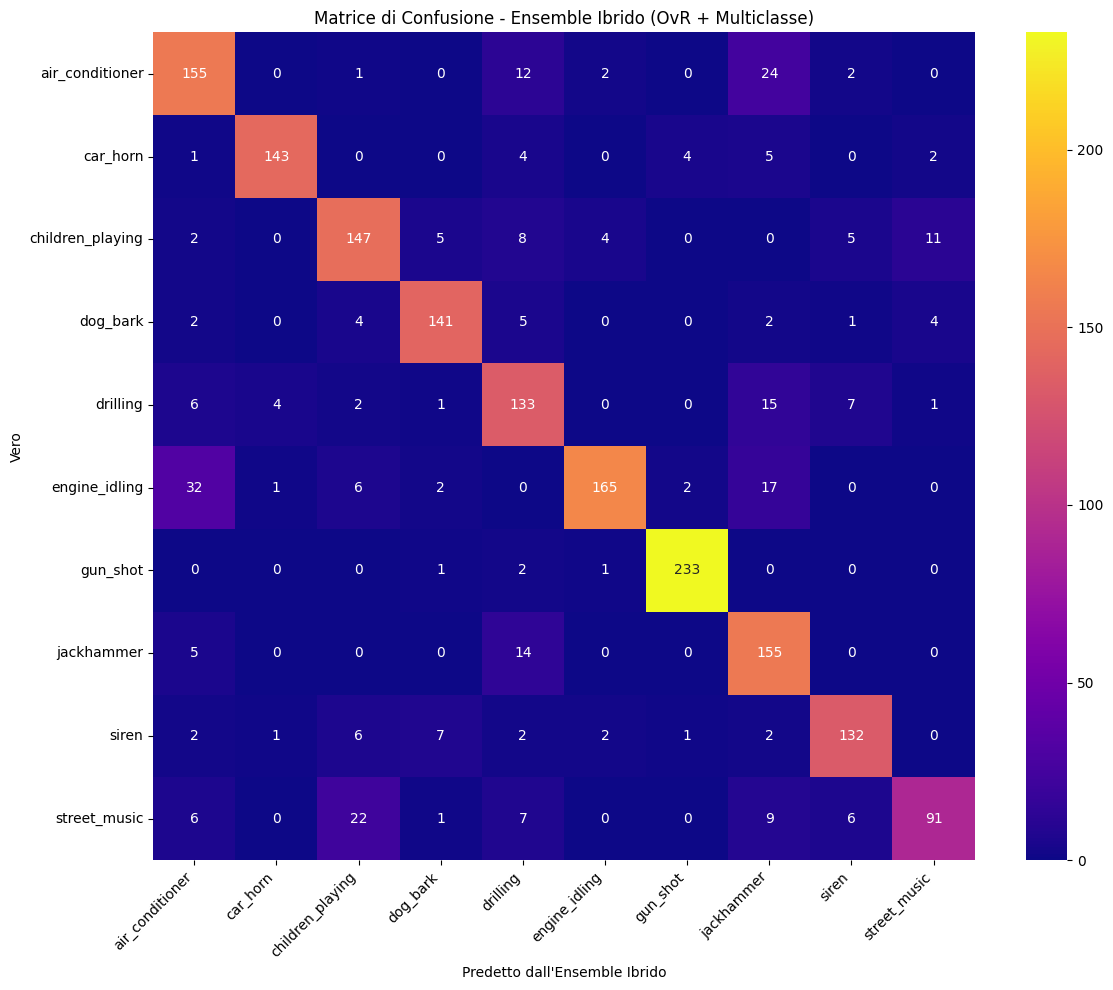

In [23]:
# ==============================================================================
#       BLOCCO FINALE: VALUTAZIONE DELL'ENSEMBLE IBRIDO (CORRETTO)
# ==============================================================================
# Esegui questo blocco dopo aver addestrato TUTTI i modelli.

print("\n--- Valutazione dell'ensemble IBRIDO (OvR + Multiclasse) ---")

# --- 1. Caricamento di TUTTI i 11 modelli ---

# 1a. Caricamento dei 10 modelli binari
binary_custom_objects = {
    "focal_loss": models.binary_focal_loss(),
    "SpecAugmentLayer": models.SpecAugmentLayer
}
loaded_binary_models = {}
for class_name in class_names:
    model_path = os.path.join(BINARY_MODELS_DIR, f"binary_model_{class_name}.keras")
    print(f"Caricando il modello binario per '{class_name}'...")
    loaded_binary_models[class_name] = tf.keras.models.load_model(model_path, custom_objects=binary_custom_objects)

# 1b. Caricamento del modello multiclasse esperto
# Assicurati che il percorso e il nome del file siano corretti!
MULTICLASS_MODEL_PATH = os.path.join(PROJECT_ROOT, "models", "model_Pipeline_B_2GRU_SpecAugment.keras")
print(f"\nCaricando il modello multiclasse da '{MULTICLASS_MODEL_PATH}'...")

# --- LA CORREZIONE È QUI ---
# Anche per il modello multiclasse, la chiave deve essere 'focal_loss',
# ma il valore deve puntare alla funzione che crea la loss CATEGORICAL.
multiclass_custom_objects = {
    "focal_loss": models.categorical_focal_loss(), # <-- CHIAVE CORRETTA
    "SpecAugmentLayer": models.SpecAugmentLayer
}
expert_multiclass_model = tf.keras.models.load_model(MULTICLASS_MODEL_PATH, custom_objects=multiclass_custom_objects)
# --- FINE CORREZIONE ---


# --- 2. Ottenere le probabilità da entrambi i sistemi ---
print("\nOttenendo le probabilità dall'ensemble OvR...")
ensemble_ovr_probas = np.zeros((len(X_test_final), num_classes))
for class_index, class_name in enumerate(class_names):
    model = loaded_binary_models[class_name]
    probas = model.predict(X_test_final, verbose=0)
    ensemble_ovr_probas[:, class_index] = probas.flatten()

print("Ottenendo le probabilità dal modello multiclasse esperto...")
expert_multiclass_probas = expert_multiclass_model.predict(X_test_final, verbose=0)


# --- 3. Logica di Decisione Ibrida ---
print("Applicando la logica di decisione ibrida...")
final_hybrid_preds = []
UNCERTAINTY_THRESHOLD = 0.80
num_uncertain_cases = 0

for i in range(len(X_test_final)):
    ovr_probas_sample = ensemble_ovr_probas[i]
    num_high_confidence_classes = np.sum(ovr_probas_sample > UNCERTAINTY_THRESHOLD)

    if num_high_confidence_classes <= 1:
        prediction = np.argmax(ovr_probas_sample)
    else:
        prediction = np.argmax(expert_multiclass_probas[i])
        num_uncertain_cases += 1

    final_hybrid_preds.append(prediction)

final_hybrid_preds = np.array(final_hybrid_preds)
print(f"\nNumero di casi incerti gestiti dal modello esperto: {num_uncertain_cases} su {len(X_test_final)} ({num_uncertain_cases/len(X_test_final):.2%})")

# --- 4. Valutazione Finale dell'Ensemble Ibrido ---
final_accuracy = accuracy_score(y_test_final, final_hybrid_preds)
print(f"\n{'='*20} PERFORMANCE FINALE DELL'ENSEMBLE IBRIDO {'='*20}")
print(f"Accuracy complessiva sul Test Set: {final_accuracy:.4f}\n")

print("--- Report di Classificazione Dettagliato (Ensemble Ibrido) ---")
print(classification_report(y_test_final, final_hybrid_preds, target_names=class_names))

print("\n--- Matrice di Confusione (Ensemble Ibrido) ---")
conf_matrix = confusion_matrix(y_test_final, final_hybrid_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='plasma',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matrice di Confusione - Ensemble Ibrido (OvR + Multiclasse)')
plt.xlabel('Predetto dall\'Ensemble Ibrido')
plt.ylabel('Vero')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()